In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot
import gc
import helpers.stc_helper as stc_helper
import time
from pycircstat2.hypothesis import rayleigh_test
from mne.stats import permutation_t_test
from mne.stats import fdr_correction
import nibabel as nib


ss = hf.settings_dict()

In [2]:
# Permutation settings
n_permutations = 2**ss['n_subjects']
alpha          = 0.05   # FDR threshold

results_dir = Path(ss["results_dir"])
results_dir.mkdir(parents=True, exist_ok=True)

from mne import spatial_src_adjacency
from mne.stats import permutation_cluster_1samp_test
from scipy.stats import t, ranksums

stim_tmin = 0.7
stim_tmax = 3.7
base_tmin = -0.5
base_tmax = 0.0



In [3]:
def morph_stc(stc, subject_index):
    subject_id = ss['subject_id_list'][subject_index]

    # name stuff
    morph_fname = op.join(ss['morph_dir'], subject_id+'-morph.h5')

    subject_morph_stat_dir = op.join(ss['stc_dir'], 'subject_morph_stat')
    morph = mne.read_source_morph(morph_fname)  # morph file

    morph_img = morph.apply(stc, mri_resolution=False, output='nifti1')

    morph_data = morph_img.get_fdata().copy()
    if subject_index == 8:
        morph_data = np.roll(morph_data, -5, axis = 1)  # fix displacement issue

    return morph_data

In [4]:
morph_data_list = []

for subject_index in ss['subject_idx_list']:
    subject = ss['subject_id_list'][subject_index]
    print("loading dataset for subject: ", subject)

    z_stats = []
    p_vals = []
    for event_id in ss['event_id_list']:

        event_name = str(event_id)
        duty_cycle = ss['event_name_list'][event_id - 1]
        subjects_dir = ss['fs_subjects_dir']
        # load stc data
        stim_stc_data = []
        base_stc_data = []
        for i in range(ss['n_trials']):
            hilbert_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-trial{i}-ret-ref-wrp-vol.stc"
            stc = mne.read_source_estimate(hilbert_stc_file)
            stim_stc = stc.copy().crop(tmin=stim_tmin, tmax=stim_tmax)
            base_stc = stc.copy().crop(tmin=base_tmin, tmax=base_tmax)
            stim_stc_data.append(stim_stc.data)
            base_stc_data.append(base_stc.data)

        stim_stc_data_stacked = np.stack(stim_stc_data)
        base_stc_data_stacked = np.stack(base_stc_data)

        # stc.data shape: (n_voxels, n_times) — phase differences in radians [-pi, pi]
        n_voxels, n_times = stc.data.shape

        z_stat = np.zeros(n_voxels)

        # Rayleigh test to get z-scores

        df = pd.read_csv(Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-mask.csv")
        stc_mask = df["voxels"].values

        for voxel_idx in range(n_voxels):
            avg_stim = np.angle(np.exp(1j * stim_stc_data_stacked[:, voxel_idx]).mean(axis=1))
            avg_base = np.angle(np.exp(1j * base_stc_data_stacked[:, voxel_idx]).mean(axis=1))

            result_stim = rayleigh_test(avg_stim)    # angles in radians
            result_base = rayleigh_test(avg_base)    # angles in radians
            # apply mask before adding results to the list
            if stc_mask[voxel_idx]:
                # z_stat[voxel_idx] = 0 - result_base.z
                continue
            z_stat[voxel_idx] = result_stim.z - result_base.z


        z_stats.append(z_stat)


    z_stc       = stc.copy().crop(0.0, 0.0 + (ss['n_events']-1)/ss['fs'])
    z_stc.data  = np.array(z_stats).T

    morph_z_data = morph_stc(z_stc, subject_index)

    morph_data_list.append(morph_z_data)      # (n_voxels,)

    del stim_stc
    del base_stc
    del stc
    del z_stc

loading dataset for subject:  0005_3SJ


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0002_TCZ


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0009_YGZ


...

  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0018_5T3


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0019_COG


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

In [20]:

#% Make mask of locations with z-values across all data.
mask_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))
mask = np.ones(mask_img.shape[0:3])

for morph_data in morph_data_list:
    for event in range(ss['n_events']):
        mask[morph_data[:,:,:,event] == 0.000000000] = 0

for event in range(ss['n_events']):
    mask_img.get_fdata()[:,:,:,event] = mask

#nib.save(mask_img, op.join(atlas_dir, stc_version+'_mask_10mm.nii'))
mask_flat = mask.flatten()

print(np.sum(mask==1))


from mne.stats import permutation_t_test

#from mlxtend.evaluate import permutation_test

#zero_mean = np.zeros(12)
n_sources = int(np.sum(mask))
n_subjects = len(morph_data_list)
#n_events = ss['n_events']
tval = np.zeros([ss['n_events'], n_sources])
pval = np.zeros([ss['n_events'], n_sources])
n_permutations = 2**n_subjects

import time
tstart = time.time()


#for event in range(n_events):
#    sample = np.zeros([n_subjects, n_sources])
#    for subject in range(n_subjects):
#        data_flat = morph_data_list[subject][:,:,:,event].flatten()
#        sample[subject, :] = data_flat[mask_flat == 1]
#    for source in range(n_sources):
#        sam = sample[:,source].reshape(12,1)
#        tval[event, source], pval[event, source], H0 = permutation_t_test(sam, n_permutations, n_jobs=1)

print("Perm. test. starting...")
for event in range(ss['n_events']):
    sample = np.zeros([n_subjects, n_sources])
    for subject in range(n_subjects):
        data_flat = morph_data_list[subject][:,:,:,event].flatten()
        sample[subject, :] = data_flat[mask_flat == 1]
    tval[event, :], pval[event, :], H0 = permutation_t_test(sample, n_permutations, n_jobs=1)
#
tend = time.time()
print('Done! Run time: '+str(int(tend - tstart))+' seconds')




194
Perm. test. starting...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Done! Run time: 0 seconds


In [10]:

tval_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))
bool_perm_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))
comb_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))

tval_data = np.zeros(tval_img.dataobj.shape)
bool_perm_data = np.zeros(bool_perm_img.get_fdata().shape)
comb_data = np.zeros(comb_img.get_fdata().shape)

bool_perm = pval <= 0.05

for event in range(ss['n_events']):
    tval_data[:,:,:,event][mask==1] = tval[event,:]
    bool_perm_data[:,:,:,event][mask==1] = bool_perm[event,:]

bool_perm_data2 = bool_perm_data.copy()
bool_perm_data2[tval_data<0] = 0

comb_data[bool_perm_data==1] = tval_data[bool_perm_data==1]

tval_img.get_fdata()[:,:,:,:] = tval_data
bool_perm_img.get_fdata()[:,:,:,:] = bool_perm_data
comb_img.get_fdata()[:,:,:,:] = comb_data


act_vol = np.sum(bool_perm_data == 1, axis=(0,1,2))
act_frac = act_vol/n_sources






In [17]:
bool_perm_data

array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
    

/tmp/ipykernel_304546/1726975980.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ss['event_name_list'], rotation=45)


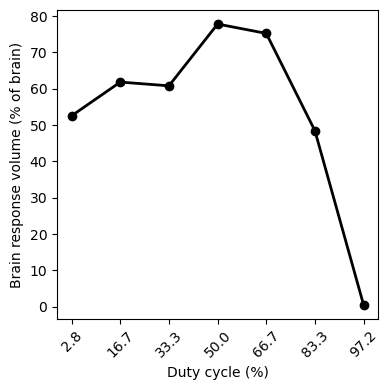

In [15]:
#stc_version = 'v003'
stc_version_list = ['v001']
#plt.close('all')
#plt.figure()
for stc_version in stc_version_list[:]:
    act_frac_p = [100 * act_frac[ii] / act_frac[3] for ii in range(len(act_frac))]

    x = [float(event_name) for event_name in ss['event_name_list']]
    x = range(7)
    fig, ax = plt.subplots(figsize=(4, 4))

    plt.plot(x, act_frac * 100, '-o', c='k', lw=2)
    #    plt.bar(x, act_frac*100, color = 'k',width=.7)
    #    plt.bar(x, act_frac)

    ax.set_xlabel('Duty cycle (%)')
    ax.set_xticklabels(ss['event_name_list'], rotation=45)
    ax.set_xticks(x)
    ax.set_ylabel('Brain response volume (% of brain)')
#    ax.set_xlim(0, 100)
plt.tight_layout()

In [12]:
colin = nib.load(Path(ss['atlas_dir']) / 'colin27_t1_tal_lin.nii')
colin_mask = nib.load(Path(ss['atlas_dir']) / 'colin27_t1_tal_lin_mask_TRANS.nii')
#fsaverage_brain.mgz
figsize = (14,7)
dpi = 150
cut_coords = (0,0)



/tmp/ipykernel_304546/3250438334.py:9: UserWarning: empty mask
  plot_stat_map(img,


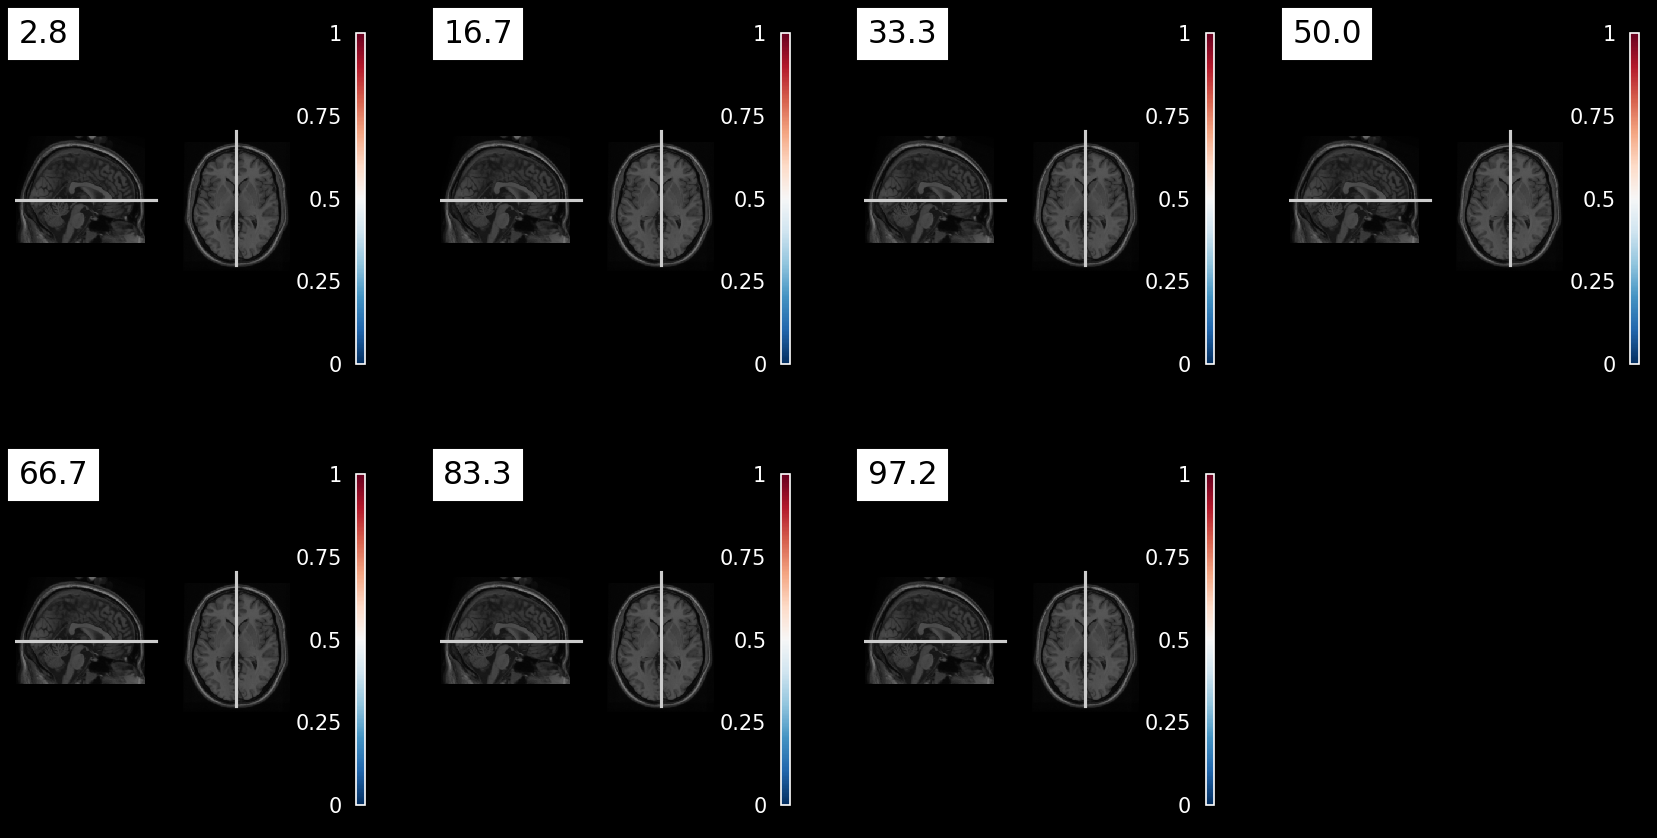

In [16]:
from nilearn.image import index_img
from nilearn.plotting import plot_stat_map

fh = plt.figure(figsize=figsize, dpi=dpi)
for event in range(ss['n_events']):
    img = index_img(bool_perm_img, event)
    ax = fh.add_subplot(2, 4, event + 1)
    title = ss['event_name_list'][event]
    plot_stat_map(img,
                  axes=ax,
                  bg_img = colin,
                  # transparency = .5,
                  vmax = 1,
                  black_bg = True,
                  title = title,
                  cut_coords = cut_coords,
                  display_mode='xz',
                  draw_cross = True,
                  annotate = False,
                  colorbar = True)

#fh.suptitle(stc_version)
fh.patch.set_facecolor((0,0,0))

plt.show()